# Fixed point TRS partial transpose boundary operator extraction.
Created 03/26/2026

Objectives:
* Check in more depth the boundary operators for the cluster state.
* Are the resulting boundary operators unique up to a phase?
* What if we plug in the exact boundray operators into the optimisation function?

# Package imports

In [1]:
import sys
sys.path.append("../..")

In [2]:
from functools import reduce
from itertools import combinations

In [3]:
import h5py
from tenpy.tools import hdf5_io
import tenpy
import tenpy.linalg.np_conserved as npc

import os

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import unitary_group

In [5]:
from SPTOptimization.SymmetryActionWithBoundaryUnitaries import SymmetryActionWithBoundaryUnitaries
from SPTOptimization.Optimizers.utils import one_site_optimization

from SPTOptimization.gradients import expectation_gradient_from_environments_and_b_tensor

In [6]:
import quimb as qu
import quimb.tensor as qtn

/Users/kierancooney/.pyenv/versions/num_spt_venv_p11/lib/python3.11/site-packages/cotengra/hyperoptimizers/hyper.py:54: UserWarning: Couldn't find `optuna`, `cmaes`, or `nevergrad` so will use completely random sampling in place of hyper-optimization.
  warnings.warn(
/Users/kierancooney/.pyenv/versions/num_spt_venv_p11/lib/python3.11/site-packages/cotengra/hyperoptimizers/hyper.py:36: UserWarning: Couldn't import `kahypar` - skipping from default hyper optimizer and using basic `labels` method instead.
  warnings.warn(
/Users/kierancooney/.pyenv/versions/num_spt_venv_p11/lib/python3.11/site-packages/cotengra/hyperoptimizers/hyper.py:73: UserWarning: Couldn't find `optuna`, `cmaes`, or `nevergrad` so will use completely random sampling in place of hyper-optimization.
  warnings.warn(


# Load data

In [7]:
DATA_DIR = r"../../data/transverse_cluster_200_site_dmrg"

In [8]:
loaded_data = list()

for local_file_name in os.listdir(DATA_DIR):
    f_name = r"{}/{}".format(DATA_DIR, local_file_name, ignore_unknown=False)
    with h5py.File(f_name, 'r') as f:
        data = hdf5_io.load_from_hdf5(f)
        loaded_data.append(data)

In [9]:
b_parameters = sorted(list(d['paramters']['B'] for d in loaded_data))

In [10]:
def get_quimb_mps(tenpy_mps):
    psi_arrays = list()
    psi_arrays.append(tenpy_mps.get_B(0, 'Th')[0, ...].to_ndarray())
    for i in range(1, tenpy_mps.L-1):
        psi_arrays.append(tenpy_mps.get_B(i).to_ndarray())
    psi_arrays.append(tenpy_mps.get_B(tenpy_mps.L-1)[..., 0].to_ndarray())
    
    out = (
        qtn
        .tensor_1d
        .MatrixProductState(psi_arrays, shape='lpr')
    )

    return out

In [11]:
psi_dict = dict()

for b in b_parameters:
    psi = next(
        d['wavefunction']
        for d in loaded_data
        if d['paramters']['B'] == b
    )

    rounded_b = round(b, 1)
    psi_dict[rounded_b] = get_quimb_mps(psi)

# Definitions

In [12]:
np_I = np.array([[1,0],[0,1]])
np_X = np.array([[0,1],[1,0]])
np_Y = np.array([[0,-1j],[1j,0]])
np_Z = np.array([[1,0],[0,-1]])

In [13]:
symmetry_actions = [
    [np_I, np_I],
    [np_I, np_X],
    [np_X, np_I],
    [np_X, np_X]
]

In [14]:
symmetry_labels = [
    'II',
    'IX',
    'XI',
    'XX'
]

## Function definitions

In [15]:
def svd_update(environment_matrix, first_boundary_guess,
               first_left_inds, second_left_inds, verbose=False):
    """
    Should comment this.
    """
    if verbose:
        print('SVD')
        print('environment_matrix')
        print(environment_matrix)
        print('first_boundary_guess')
        print(first_boundary_guess)

    first_env_matrix = (first_boundary_guess & environment_matrix) ^ ...

    if verbose:
        print('first_env_matrix')
        print(first_env_matrix)

    svd = first_env_matrix.split(
        left_inds=second_left_inds,
        absorb=None,
        bond_ind='s'
    )

    first_score = np.sum(svd.tensors[1].data)
    first_unitary = (svd.tensors[0] & svd.tensors[2]) ^ ...
    first_unitary = first_unitary.conj()
    
    second_env_matrix = (first_unitary & environment_matrix) ^ ...

    svd = second_env_matrix.split(
        left_inds=first_left_inds,
        absorb=None,
        bond_ind='s'
    )

    second_score = np.sum(svd.tensors[1].data)
    second_unitary = (svd.tensors[0] & svd.tensors[2]) ^ ...
    second_unitary = second_unitary.conj()

    return (
        [first_unitary, second_unitary],
        [first_score, second_score]
    )

In [16]:
def iterated_svd_updates(environment_matrix, first_ket_inds,
                         second_ket_inds, first_bra_inds, num_iters, verbose=False):
    scores = list()

    # Hard code warning!
    rand_unitary = unitary_group.rvs(4)
    rand_unitary = np.reshape(rand_unitary, (2,2,2,2))

    boundary_guess = qtn.tensor_core.Tensor(
        rand_unitary,
        inds=first_ket_inds+first_bra_inds
    )

    for i in range(num_iters):
        if verbose:
            print(i)
            print(boundary_guess)
            print(environment_matrix)
            print(first_ket_inds)
            print(second_ket_inds)

        current_out = svd_update(
            environment_matrix,
            boundary_guess,
            first_ket_inds,
            second_ket_inds,
            verbose
        )
        scores.extend(current_out[1])
        boundary_guess = current_out[0][1]


    return (current_out[0], scores)

In [17]:
x_gate = qtn.Tensor(data=np_X, inds=('b', 'k'))

In [18]:
def find_boundary_operators(psi, leftmost_symmetry_site,
    rightmost_symmetry_site, num_boundary_sites, num_iters):

    symmetry_sites = list(range(leftmost_symmetry_site, rightmost_symmetry_site+1))
    all_sites = list(range(
        leftmost_symmetry_site-num_boundary_sites,
        rightmost_symmetry_site+1+num_boundary_sites
    ))

    rho = psi.partial_trace_to_mpo(
        all_sites,
        rescale_sites=False
    )
    
    rho_2 = rho.copy()

    rho.reindex(
        {f'{s}{i}': f'{s}{i}_1' for s in ['k', 'b'] for i in all_sites},
        inplace=True
    )
    
    rho_2.reindex(
        {f'{s}{i}': f'{s}{i}_2' for s in ['k', 'b'] for i in all_sites},
        inplace=True
    )
    
    x_gates_b = [
        x_gate.copy().reindex({'b': f'b{i}_1', 'k': f'b{i}_2'})
        for i in symmetry_sites
    ]
    
    x_gates_k = [
        x_gate.copy().reindex({'b': f'k{i}_1', 'k': f'k{i}_2'})
        for i in symmetry_sites
    ]

    two_sided_environment_matrix = qtn.tensor_core.TensorNetwork(
        [
            rho,
            rho_2,
            *x_gates_b,
            *x_gates_k
        ]
    )
    two_sided_environment_matrix.contract(inplace=False)

    left_boundary_sites = list(range(
        leftmost_symmetry_site-num_boundary_sites,
        leftmost_symmetry_site
    ))

    right_boundary_sites = list(range(
        rightmost_symmetry_site+1,
        rightmost_symmetry_site+1+num_boundary_sites
    ))

    left_boundary_indices = [
        f'{bk}{i}_{j}'
        for bk in ['b', 'k']
        for i in left_boundary_sites
        for j in [1, 2]
    ]

    split_two_sided_environment_matrix = two_sided_environment_matrix.split(
        left_inds=left_boundary_indices,
        absorb=None,
        bond_ind='s'
    )

    two_sided_sing_vals = (
        split_two_sided_environment_matrix
        .tensors[1]
        .data
    )

    left_env_matrix = split_two_sided_environment_matrix.tensors[0].isel({'s': 0})
    right_env_matrix = split_two_sided_environment_matrix.tensors[2].isel({'s': 0})

    left_boundary_ops, left_scores = iterated_svd_updates(
        left_env_matrix,
        [f'k{i}_2' for i in left_boundary_sites],
        [f'k{i}_1' for i in left_boundary_sites],
        [f'b{i}_1' for i in left_boundary_sites],
        num_iters
    )

    right_boundary_ops, right_scores = iterated_svd_updates(
        right_env_matrix,
        [f'k{i}_2' for i in right_boundary_sites],
        [f'k{i}_1' for i in right_boundary_sites],
        [f'b{i}_1' for i in right_boundary_sites],
        num_iters
    )

    return (
        left_boundary_ops,
        right_boundary_ops,
        left_scores,
        right_scores,
        two_sided_sing_vals
    )

# Analysis

## Single test

In [19]:
results = find_boundary_operators(
    psi_dict[0],
    60,
    139,
    2,
    20
)

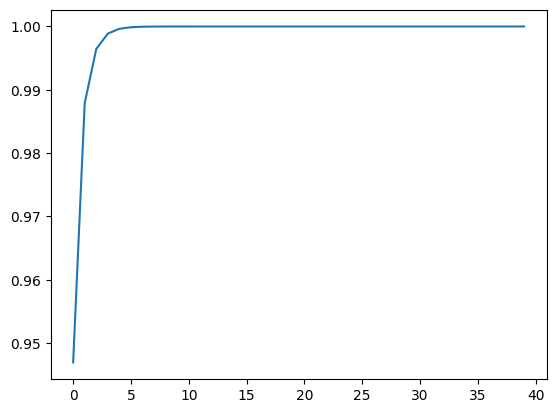

In [21]:
plt.plot(results[2])

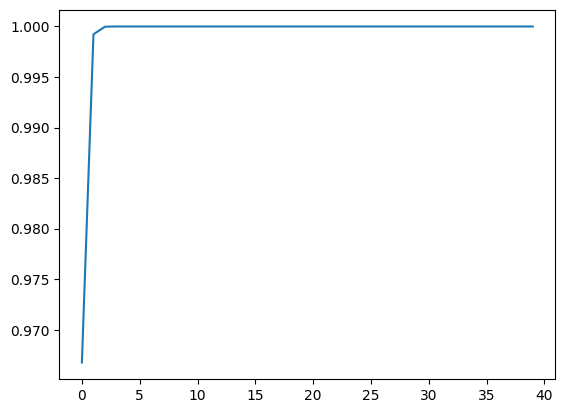

In [22]:
plt.plot(results[3])

In [23]:
results[4]

array([0.0625])

In [27]:
results[0][0].data

array([[[[-0.57571581+0.12597425j,  0.61135594-0.13990102j],
         [ 0.25985073-0.26881422j,  0.34254988+0.04721771j]],

        [[ 0.66754624+0.01262539j,  0.47674845+0.12837589j],
         [-0.25773181-0.02636733j,  0.47565483+0.13070853j]]],


       [[[-0.21685716-0.08848858j, -0.20675432-0.40218008j],
         [-0.35876437+0.25777445j,  0.25153727+0.69441778j]],

        [[-0.13640231+0.36529654j,  0.39303241+0.06270196j],
         [-0.22177085+0.74077915j, -0.27141465-0.13395847j]]]])

In [31]:
results[1][1]

Tensor(shape=(2, 2, 2, 2), inds=('k140_2', 'k141_2', 'b140_1', 'b141_1'), tags=oset(['I58', 'I59', 'I60', 'I61', 'I62', 'I63', 'I64', 'I65', 'I66', 'I67', 'I68', 'I69', 'I70', 'I71', 'I72', 'I73', 'I74', 'I75', 'I76', 'I77', 'I78', 'I79', 'I80', 'I81', 'I82', 'I83', 'I84', 'I85', 'I86', 'I87', 'I88', 'I89', 'I90', 'I91', 'I92', 'I93', 'I94', 'I95', 'I96', 'I97', 'I98', 'I99', 'I100', 'I101', 'I102', 'I103', 'I104', 'I105', 'I106', 'I107', 'I108', 'I109', 'I110', 'I111', 'I112', 'I113', 'I114', 'I115', 'I116', 'I117', 'I118', 'I119', 'I120', 'I121', 'I122', 'I123', 'I124', 'I125', 'I126', 'I127', 'I128', 'I129', 'I130', 'I131', 'I132', 'I133', 'I134', 'I135', 'I136', 'I137', 'I138', 'I139', 'I140', 'I141']))

## Are the boundary operators unique?

In [32]:
def similarity_score(op_1, op_2):
    np_op_1 = op_1.data.reshape(4,4)
    np_op_2 = op_2.data.reshape(4,4)

    cross_term = np.trace(np_op_1@(np_op_2.conj().T))

    return (
        np.linalg.norm(np_op_1)**2
        + np.linalg.norm(np_op_2)**2
        - 2*np.abs(cross_term)
    )

In [33]:
results = [
    find_boundary_operators(
        psi_dict[0],
        60,
        139,
        2,
        20
    )
    for _ in range(30)
]

In [34]:
len(results)

30

In [39]:
def get_all_similarities(op_list):
    if len(op_list) >= 2:
        head, tail = op_list[0], op_list[1:]
        current_similarities = [
            similarity_score(head, other)
            for other in tail
        ]
        return current_similarities + get_all_similarities(tail)
    else:
        return list()

In [40]:
left_sims_1 = get_all_similarities(
    [l[0][0] for l in results]
)

(array([ 3.,  3., 10., 22., 30., 69., 79., 78., 86., 55.]),
 array([2.62813088, 3.15804624, 3.6879616 , 4.21787696, 4.74779232,
        5.27770768, 5.80762303, 6.33753839, 6.86745375, 7.39736911,
        7.92728447]),
 <BarContainer object of 10 artists>)

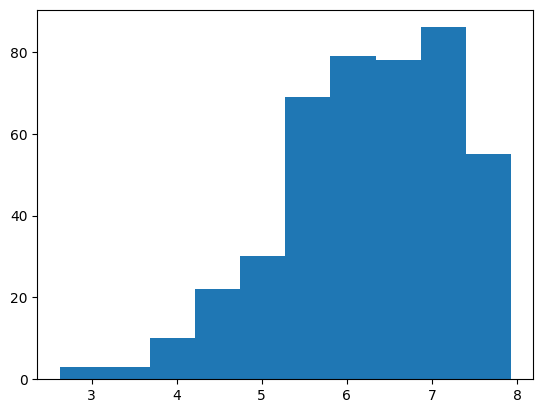

In [42]:
plt.hist(left_sims_1)

In [43]:
pd.Series(left_sims_1).describe()

count    435.000000
mean       6.243000
std        1.020589
min        2.628131
25%        5.619641
50%        6.338703
75%        7.043202
max        7.927284
dtype: float64

In [44]:
left_sims_2 = get_all_similarities(
    [l[0][1] for l in results]
)

(array([ 3.,  3., 10., 22., 30., 69., 79., 78., 86., 55.]),
 array([2.62855468, 3.15842677, 3.68829887, 4.21817096, 4.74804305,
        5.27791514, 5.80778724, 6.33765933, 6.86753142, 7.39740352,
        7.92727561]),
 <BarContainer object of 10 artists>)

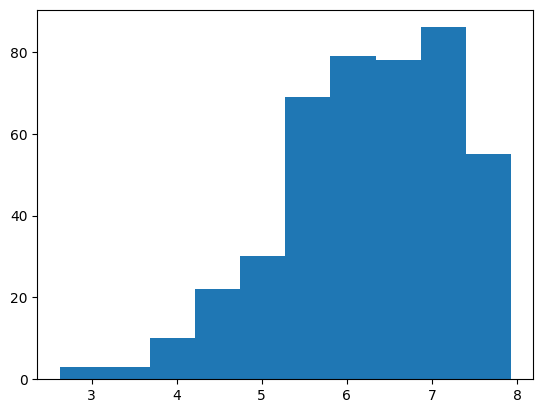

In [45]:
plt.hist(left_sims_2)

In [46]:
pd.Series(left_sims_2).describe()

count    435.000000
mean       6.243003
std        1.020591
min        2.628555
25%        5.619649
50%        6.338703
75%        7.043202
max        7.927276
dtype: float64

In [49]:
left_final_scores = [l[2][-1] for l in results]

In [50]:
pd.Series(left_final_scores).describe()

count    3.000000e+01
mean     1.000000e+00
std      8.992980e-09
min      1.000000e+00
25%      1.000000e+00
50%      1.000000e+00
75%      1.000000e+00
max      1.000000e+00
dtype: float64

In [51]:
right_sims_1 = get_all_similarities(
    [l[1][0] for l in results]
)

(array([  1.,   0.,   2.,  12.,  14.,  43.,  78., 109., 100.,  76.]),
 array([1.35360823, 2.01239695, 2.67118567, 3.3299744 , 3.98876312,
        4.64755184, 5.30634057, 5.96512929, 6.62391801, 7.28270673,
        7.94149546]),
 <BarContainer object of 10 artists>)

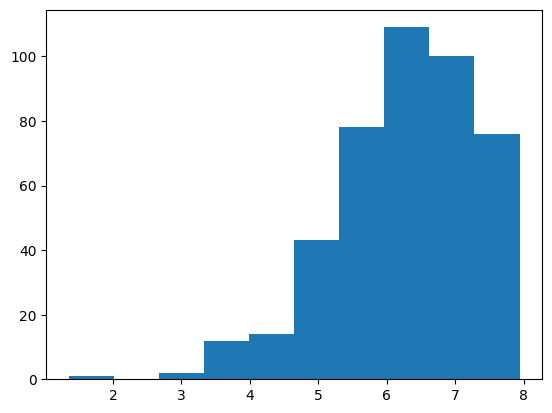

In [52]:
plt.hist(right_sims_1)

In [54]:
pd.Series(right_sims_1).describe()

count    435.000000
mean       6.275306
std        1.031058
min        1.353608
25%        5.632859
50%        6.448718
75%        7.075196
max        7.941495
dtype: float64

In [55]:
right_sims_2 = get_all_similarities(
    [l[1][1] for l in results]
)

(array([  1.,   0.,   2.,  12.,  14.,  43.,  78., 109., 100.,  76.]),
 array([1.35360823, 2.01239695, 2.67118567, 3.3299744 , 3.98876312,
        4.64755184, 5.30634057, 5.96512929, 6.62391801, 7.28270673,
        7.94149546]),
 <BarContainer object of 10 artists>)

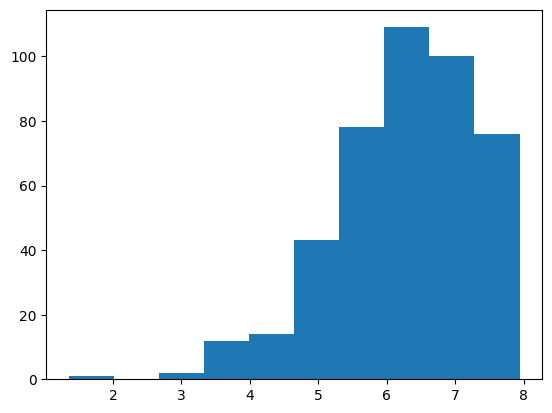

In [56]:
plt.hist(right_sims_2)

In [57]:
pd.Series(right_sims_2).describe()

count    435.000000
mean       6.275305
std        1.031060
min        1.353608
25%        5.632859
50%        6.448718
75%        7.075196
max        7.941495
dtype: float64

In [58]:
right_final_scores = [l[3][-1] for l in results]

In [59]:
pd.Series(left_final_scores).describe()

count    3.000000e+01
mean     1.000000e+00
std      8.992980e-09
min      1.000000e+00
25%      1.000000e+00
50%      1.000000e+00
75%      1.000000e+00
max      1.000000e+00
dtype: float64

Take an example:

In [61]:
right_sims_1[0]

5.798611514094181

In [63]:
results[0][1][1].data

array([[[[ 0.12823986-0.38879192j,  0.19988691-0.52088899j],
         [ 0.67820442+0.05937524j,  0.23929914+0.01909289j]],

        [[-0.20716498-0.46878973j,  0.18980567+0.4761245j ],
         [ 0.24961126-0.20957532j, -0.4598182 +0.39615371j]]],


       [[[ 0.1170741 +0.63588847j,  0.27287171-0.16910297j],
         [ 0.34207487-0.30163513j, -0.51349244-0.08491927j]],

        [[-0.37697031-0.09770948j, -0.14958324-0.54824194j],
         [-0.21800347+0.41804459j, -0.52441098+0.16765502j]]]])

In [64]:
results[1][1][1].data

array([[[[-0.07085815+0.48810446j,  0.37506421+0.30722227j],
         [-0.03589372+0.37980459j, -0.4050404 -0.46051804j]],

        [[ 0.57719573+0.13279705j, -0.45024767+0.32790249j],
         [ 0.15749821+0.48538399j,  0.27591257+0.0493555j ]]],


       [[[ 0.380067  +0.3378042j ,  0.41284455+0.30441954j],
         [-0.34031338-0.46483744j,  0.33230555+0.18976696j]],

        [[ 0.37458466+0.08406497j, -0.41223946-0.14712259j],
         [-0.03736944-0.51065966j, -0.3031526 -0.55404126j]]]])

In [70]:
X1 = results[0][1][1].data
X2 = results[1][1][1].data

diffs = list()

for i in np.linspace(0, 1, 100):
    phase = np.exp(2*np.pi*1j*i)
    diffs.append(np.linalg.norm(X1 - phase*X2)**2)

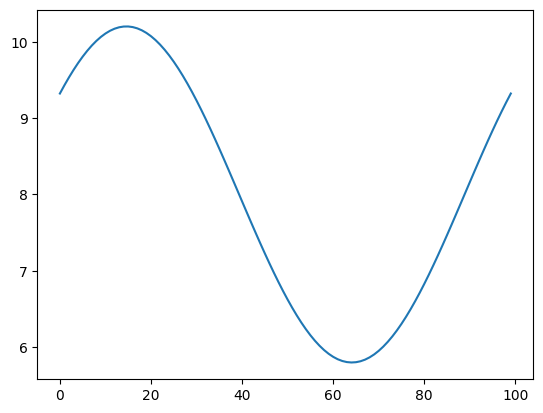

In [71]:
plt.plot(diffs)

In [72]:
np.min(diffs)

5.798653976134727

In [73]:
right_sims_2[0]

5.798611514094185

Consistent. So there is degeneracy. Dang.

In [40]:
final_scores = list()

for i, k in enumerate(results.keys()):
    final_scores.append(
        results[k][2][-1]
        *results[k][3][-1]
        *left_right_cut_schmidt_values[i]
    )

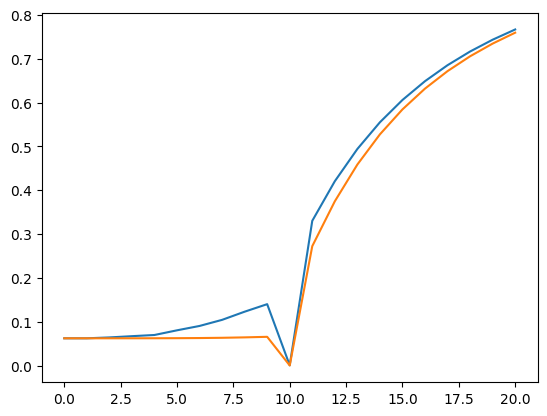

In [41]:
plt.plot(final_scores)
plt.plot(left_right_cut_schmidt_values)

In [44]:
psi = psi_dict[0]

In [45]:
psi.schmidt_values(80)

array([0.5, 0.5])

In [46]:
np.sum(psi.schmidt_values(80)**2)*np.sum(psi.schmidt_values(121)**2)

0.24999999999999906

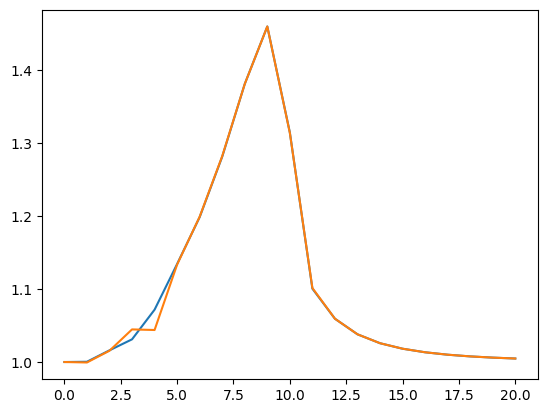

In [47]:
plt.plot([v[2][-1] for v in results.values()])
plt.plot([v[3][-1] for v in results.values()])

Calculate expected final answer.

In [51]:
predicted_opt_scores = [
    np.sum(psi.schmidt_values(60)**2)*np.sum(psi.schmidt_values(140)**2)
    for psi in psi_dict.values()
]

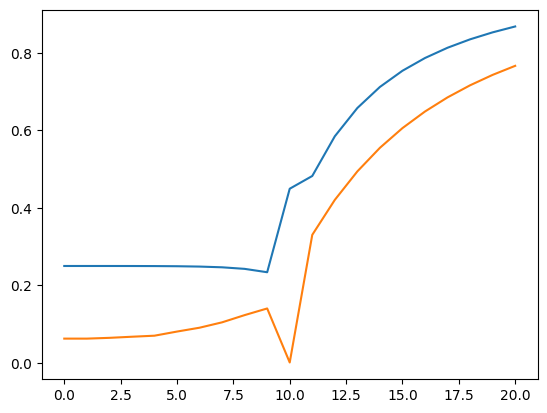

In [53]:
plt.plot(predicted_opt_scores)
plt.plot(final_scores)

In [54]:
predicted_opt_scores = np.array(predicted_opt_scores)
final_scores = np.array(final_scores)

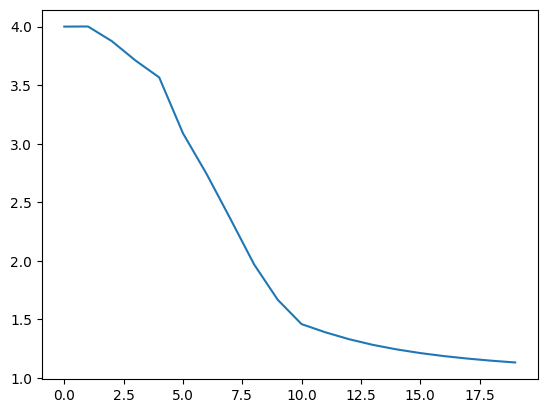

In [56]:
plt.plot(np.delete((predicted_opt_scores/final_scores), 10))

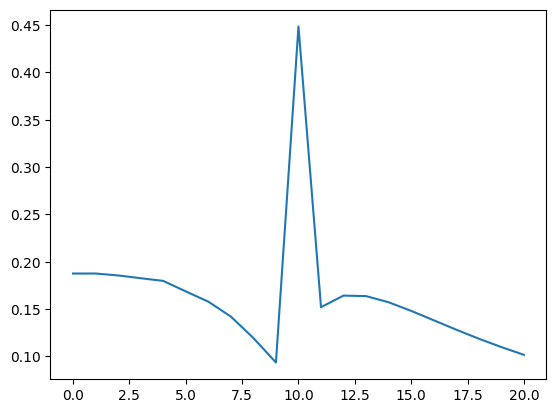

In [57]:
plt.plot(predicted_opt_scores - final_scores)

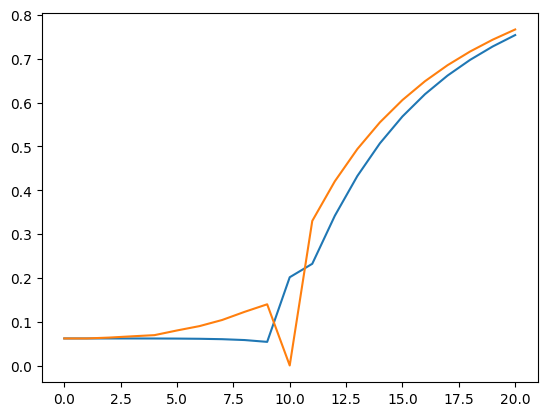

In [58]:
plt.plot(predicted_opt_scores**2)
plt.plot(final_scores)

In [61]:
predicted_opt_scores_2 = [
    np.sum(psi.schmidt_values(60)**3)*np.sum(psi.schmidt_values(140)**3)
    for psi in psi_dict.values()
]

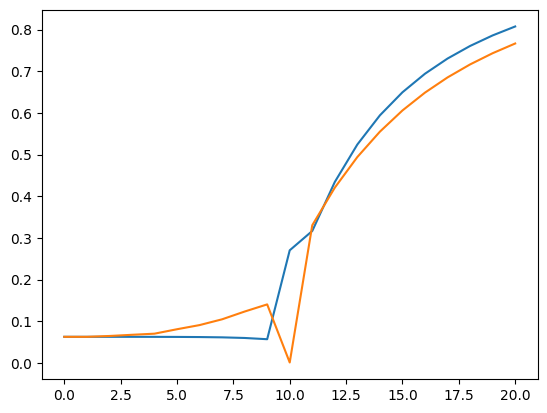

In [62]:
plt.plot(predicted_opt_scores_2)
plt.plot(final_scores)

# Find traditional environment matrices

## Make function

In [64]:
def get_direct_environment_matrices(psi, leftmost_symmetry_site,
    rightmost_symmetry_site, num_boundary_sites):
    
    symmetry_sites = list(range(leftmost_symmetry_site, rightmost_symmetry_site+1))
    all_sites = list(range(
        leftmost_symmetry_site-num_boundary_sites,
        rightmost_symmetry_site+1+num_boundary_sites
    ))

    left_boundary_sites = list(range(
        leftmost_symmetry_site-num_boundary_sites,
        leftmost_symmetry_site
    ))

    right_boundary_sites = list(range(
        rightmost_symmetry_site+1,
        rightmost_symmetry_site+1+num_boundary_sites
    ))

    psi_2 = psi.copy(deep=True)
    symmetry_tags = [f'I{i}' for i in symmetry_sites]
    for t in psi_2.select(symmetry_tags, which='any'):
        t.conj(inplace=True)

    psi_b = (
        psi
        .conj()
        .reindex({f'k{i}':f'b{i}' for i in all_sites})
    )

    x_gates = [
        x_gate.copy().reindex({'b': f'b{i}', 'k': f'k{i}'})
        for i in symmetry_sites
    ]
    
    leftright_env_matrix = (
        qtn.tensor_core.TensorNetwork(
            [
                psi_2,
                psi_b,
                *x_gates
            ]
        )
        .contract()
    )

    left_boundary_indices = [
        f'{bk}{i}'
        for bk in ['b', 'k']
        for i in left_boundary_sites
    ]

    svd = leftright_env_matrix.split(
        left_inds=left_boundary_indices,
        absorb=None,
        bond_ind='s'
    )

    left_right_singular_vals = svd.tensors[1].data

    left_env_matrix = svd.tensors[0].isel({'s': 0})
    right_env_matrix = svd.tensors[2].isel({'s': 0})

    return (left_env_matrix, right_env_matrix, left_right_singular_vals)

## Loop and check

In [65]:
leftmost_symmetry_site = 60
rightmost_symmetry_site = 139
num_boundary_sites = 2

direct_env_matrices = dict()

for k, psi in psi_dict.items():
    direct_env_matrices[k] = get_direct_environment_matrices(
        psi,
        leftmost_symmetry_site,
        rightmost_symmetry_site,
        num_boundary_sites
    )

Check singular values

In [66]:
[
    direct_env_matrices[k][2].shape
    for k in psi_dict
]

[(1,),
 (1,),
 (1,),
 (1,),
 (1,),
 (1,),
 (1,),
 (3,),
 (3,),
 (4,),
 (5,),
 (4,),
 (3,),
 (3,),
 (3,),
 (3,),
 (1,),
 (1,),
 (1,),
 (1,),
 (1,)]

In [67]:
[
    direct_env_matrices[k][2][1]
    for k in psi_dict
    if len(direct_env_matrices[k][2]) > 1
]

[2.7330810751184466e-10,
 7.231808139904245e-08,
 1.0759913208452046e-05,
 0.00679286102052588,
 1.2862034628846933e-05,
 4.0121384855293915e-07,
 2.0894588563716567e-08,
 1.2596774537886015e-09,
 8.803134264181871e-11]

Small singular values again.

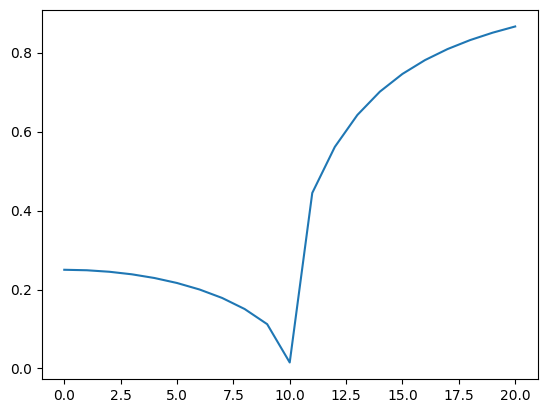

In [68]:
plt.plot([
    direct_env_matrices[k][2][0]
    for k in psi_dict
])

Qualitatively similar to previous left/right schmidt value.

Loop and check expectations

In [69]:
reindexing_dict = {
    'k140_1': 'k140',
    'k141_1': 'k141',
    'b140_1': 'b140',
    'b141_1': 'b141',
    'k140_2': 'k140',
    'k141_2': 'k141',
    'b140_2': 'b140',
    'b141_2': 'b141'
}

Tranpose of a tensor network.

In [88]:
right_boundary_ops[0].inds

('k140_1', 'k141_1', 'b140_2', 'b141_2')

In [89]:
kb_tranpose_dict = {
    'k': 'b', 'b': 'k'
}

In [96]:
def clean_op_indices(op_t):
    clean_reindex_dict = {
        ind: ('').join(ind.split('_')[:-1])
        for ind in op_t.inds
    }

    return op_t.reindex(clean_reindex_dict)

In [99]:
def tranpose_tensor_network(t):
    transpose_reindex_dict = {
        ind: kb_tranpose_dict[ind[0]] + ind[1:]
        for ind in t.inds
    }

    return t.reindex(transpose_reindex_dict)

In [102]:
comparison_results = dict()

for k in results:
    triple = direct_env_matrices[k]

    left_env_matrix = triple[0]
    right_env_matrix = triple[1]

    expected_left_score = np.sum(left_env_matrix.singular_values(
        left_inds=[
            'k58',
            'k59'
        ]
    ))

    expected_right_score = np.sum(right_env_matrix.singular_values(
        left_inds=[
        'k140',
        'k141'
        ]
    ))

    left_boundary_ops, right_boundary_ops, *_ = results[k]

    left_scores = list()
    for op in left_boundary_ops:
        clean_op = clean_op_indices(op)
        ops = [
            clean_op,
            clean_op.conj(),
            tranpose_tensor_network(clean_op),
            tranpose_tensor_network(clean_op).conj()
        ]
        scores = [
            np.abs((x & left_env_matrix) ^ ...)
            for x in ops
        ]
        left_scores.append(scores)

    right_scores = list()
    for op in right_boundary_ops:
        clean_op = clean_op_indices(op)
        ops = [
            clean_op,
            clean_op.conj(),
            tranpose_tensor_network(clean_op),
            tranpose_tensor_network(clean_op).conj()
        ]
        scores = [
            np.abs((x & right_env_matrix) ^ ...)
            for x in ops
        ]
        right_scores.append(scores)

    out = [
        expected_left_score,
        expected_right_score,
        left_scores,
        right_scores
    ]

    comparison_results[k] = out

In [104]:
comparison_results[0]

[2.0,
 2.0,
 [[0.47031552173579677,
   0.47031552173579677,
   0.47031552173579677,
   0.47031552173579677],
  [0.470315521735798,
   0.470315521735798,
   0.47031552173579805,
   0.47031552173579805]],
 [[0.2908929429640953,
   0.2908929429640953,
   0.2908929429640951,
   0.2908929429640951],
  [0.2908929429641104,
   0.2908929429641104,
   0.2908929429641102,
   0.2908929429641102]]]

In [112]:
comparison_results[0.7]

[1.9999999992571977,
 1.999999999256745,
 [[1.0050126158524856e-10,
   1.0050126158524856e-10,
   1.0050127395753179e-10,
   1.0050127395753179e-10],
  [7.412931487324337e-11,
   7.412931487324337e-11,
   7.41292644392833e-11,
   7.41292644392833e-11]],
 [[2.476402798363646e-10,
   2.476402798363646e-10,
   2.4764046925739665e-10,
   2.4764046925739665e-10],
  [1.872582872824822e-10,
   1.872582872824822e-10,
   1.8725808793447987e-10,
   1.8725808793447987e-10]]]

In [111]:
comparison_results[2.0]

[1.0000000007206402,
 1.0000000007206316,
 [[1.0000000002399403,
   1.0000000002399403,
   1.0000000002399403,
   1.0000000002399403],
  [1.0000000002400027,
   1.0000000002400027,
   1.0000000002400027,
   1.0000000002400027]],
 [[1.0000000002402045,
   1.0000000002402045,
   1.0000000002402045,
   1.0000000002402045],
  [1.0000000002402074,
   1.0000000002402074,
   1.0000000002402074,
   1.0000000002402074]]]

These results look very wrong...

In [113]:
np.round(direct_env_matrices[0][1].data,3)

array([[[[-0. ,  0. ],
         [-0.5, -0. ]],

        [[-0. , -0. ],
         [ 0. ,  0.5]]],


       [[[ 0.5, -0. ],
         [-0. , -0. ]],

        [[ 0. , -0.5],
         [-0. , -0. ]]]])

Seems reasonable to me.

In [114]:
results[0][1][0]

Tensor(shape=(2, 2, 2, 2), inds=('k140_1', 'k141_1', 'b140_2', 'b141_2'), tags=oset(['I58', 'I59', 'I60', 'I61', 'I62', 'I63', 'I64', 'I65', 'I66', 'I67', 'I68', 'I69', 'I70', 'I71', 'I72', 'I73', 'I74', 'I75', 'I76', 'I77', 'I78', 'I79', 'I80', 'I81', 'I82', 'I83', 'I84', 'I85', 'I86', 'I87', 'I88', 'I89', 'I90', 'I91', 'I92', 'I93', 'I94', 'I95', 'I96', 'I97', 'I98', 'I99', 'I100', 'I101', 'I102', 'I103', 'I104', 'I105', 'I106', 'I107', 'I108', 'I109', 'I110', 'I111', 'I112', 'I113', 'I114', 'I115', 'I116', 'I117', 'I118', 'I119', 'I120', 'I121', 'I122', 'I123', 'I124', 'I125', 'I126', 'I127', 'I128', 'I129', 'I130', 'I131', 'I132', 'I133', 'I134', 'I135', 'I136', 'I137', 'I138', 'I139', 'I140', 'I141']))

In [115]:
np.round(results[0][1][0].data, 3)

array([[[[ 0.008+0.464j,  0.676-0.478j],
         [ 0.114+0.155j, -0.218+0.124j]],

        [[-0.006+0.505j, -0.318+0.071j],
         [ 0.003+0.702j,  0.29 -0.248j]]],


       [[[ 0.023-0.006j, -0.236+0.209j],
         [-0.036+0.352j, -0.607+0.638j]],

        [[ 0.718-0.115j,  0.285+0.167j],
         [-0.565+0.16j ,  0.127+0.024j]]]])

# Conclusion
Initial results don't look promising. Will focus on $B=0$ fixed point state next.